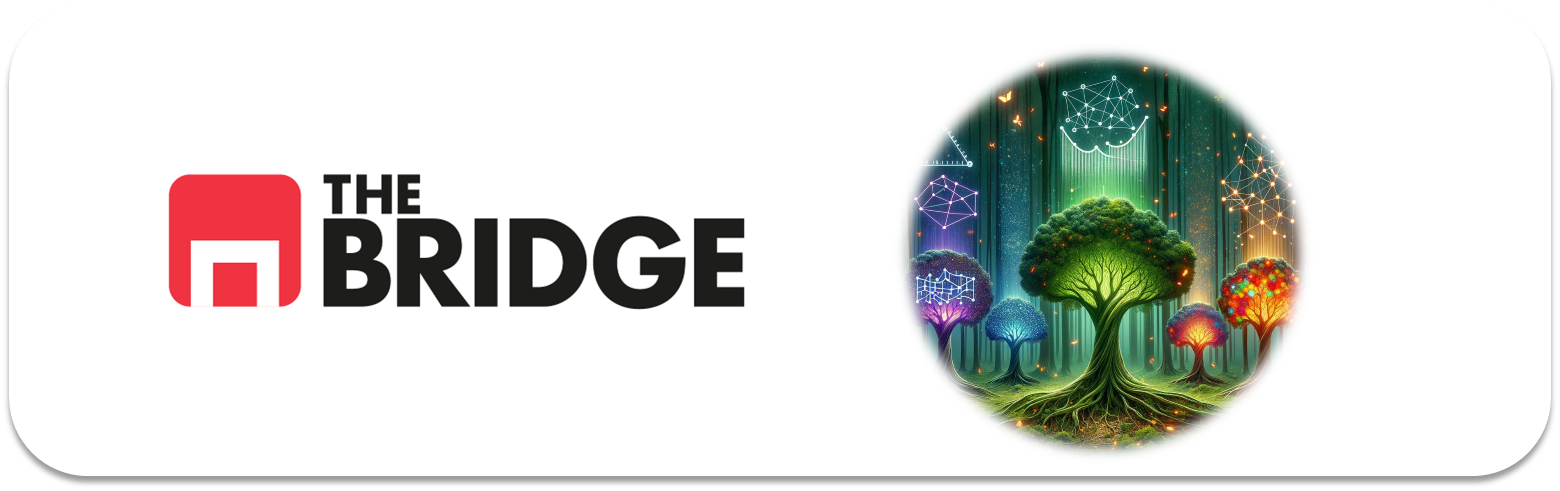

## PRACTICA OBLIGATORIA: **Arboles de Decisión y Ajuste de Hiperparámetros**

* La práctica obligatoria de esta unidad consiste en encontrar el mejor modelo para resolver un problema de predicción de si los destinatarios de una campaña de marketing adquirirán un producto concreto. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [88]:
import bootcampviztools as bt

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.metrics import ConfusionMatrixDisplay, classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression


pd.options.mode.copy_on_write = True

C:\Users\anaco\AppData\Local\Temp\ipykernel_16436\1614907002.py:15: Pandas4Warning: The 'mode.copy_on_write' option is deprecated. Copy-on-Write can no longer be disabled (it is always enabled with pandas >= 3.0), and setting the option has no impact. This option will be removed in pandas 4.0.
  pd.options.mode.copy_on_write = True


### Descripción

En el directorio data encontrarás un dataset que contiene datos relacionados con campañas de marketing directo de una institución bancaria portuguesa (es el dataset "Bank Marketing" de la UCI Machine Learning Repository). Los datos se recopilaron de campañas de marketing telefónico, donde el objetivo principal era predecir si el cliente se suscribiría a un depósito a plazo.

La práctica consiste en completar el proceso de creación de un modelo basado en árboles de decisión que permita predecir si un cliente (dadas unas características similares a las del dataset) "comprará" el depósito a plazo. Sigue los pasos necesarios de un proceso de ML para crear el modelo, optimizar sus hiperparámetros, comparar los resultados de esa optimización con una regresión logística (sin optimizar, con sus hiperparámetros por defecto) y finalmente evaluarlo contra test y hacer una pequeña valoración del resultado obtenido.

Tendrás que hacer la limpieza, split, minieda, selección, tratamiento, primeros entrenamientos, optimización, comparación y evaluación según tu mejor criterio. Eso sí, es obligatorio:
- Identificar el target y analizar su distribución
- Realizar una optimización de hiperparámetros, escogiendo un grid medianemante razonado
- Comparar con el modelo baseline
- Evaluar contra test

AYUDA: La dirección del banco nos proporciona estas notas (en inglés):

 
   **bank client data:**  
   1 - age (numeric)  
   2 - job : type of job (categorical: "admin.","unknown","unemployed","management","housemaid","entrepreneur","student",
                                       "blue-collar","self-employed","retired","technician","services")   
   3 - marital : marital status (categorical: "married","divorced","single"; note: "divorced" means divorced or widowed)  
   4 - education (categorical: "unknown","secondary","primary","tertiary")  
   5 - default: has credit in default? (binary: "yes","no")  
   6 - balance: average yearly balance, in euros (numeric)   
   7 - housing: has housing loan? (binary: "yes","no")  
   8 - loan: has personal loan? (binary: "yes","no")   

   **related with the last contact of the current campaign:**  
   9 - contact: contact communication type (categorical: "unknown","telephone","cellular")   
  10 - day: last contact day of the month (numeric)  
  11 - month: last contact month of year (categorical: "jan", "feb", "mar", ..., "nov", "dec")  
  12 - duration: last contact duration, in seconds (numeric)    

   **other attributes:**  
  13 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)  
  14 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric, -1 means client was not previously contacted)  
  15 - previous: number of contacts performed before this campaign and for this client (numeric)  
  16 - poutcome: outcome of the previous marketing campaign (categorical: "unknown","other","failure","success")

  

In [89]:
df = pd.read_csv("./data/bank-full.csv", sep = ";")

In [3]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [ ]:
# recomendable hacer una copia del df para trabajar desde ahi!!

In [90]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 5.9 MB


In [ ]:
df.describe(include="all") # para ver nulos

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
count,45211.000000,45211,45211,45211,45211,45211.000000,45211,45211,45211,45211.000000,45211,45211.000000,45211.000000,45211.000000,45211.000000,45211,45211
unique,NaN,12,3,4,2,NaN,2,2,3,NaN,12,NaN,NaN,NaN,NaN,4,2
top,NaN,blue-collar,married,secondary,no,NaN,yes,no,cellular,NaN,may,NaN,NaN,NaN,NaN,unknown,no
freq,NaN,9732,27214,23202,44396,NaN,25130,37967,29285,NaN,13766,NaN,NaN,NaN,NaN,36959,39922
mean,40.936210,NaN,NaN,NaN,NaN,1362.272058,NaN,NaN,NaN,15.806419,NaN,258.163080,2.763841,40.197828,0.580323,NaN,NaN
std,10.618762,NaN,NaN,NaN,NaN,3044.765829,NaN,NaN,NaN,8.322476,NaN,257.527812,3.098021,100.128746,2.303441,NaN,NaN
min,18.000000,NaN,NaN,NaN,NaN,-8019.000000,NaN,NaN,NaN,1.000000,NaN,0.000000,1.000000,-1.000000,0.000000,NaN,NaN
25%,33.000000,NaN,NaN,NaN,NaN,72.000000,NaN,NaN,NaN,8.000000,NaN,103.000000,1.000000,-1.000000,0.000000,NaN,NaN
50%,39.000000,NaN,NaN,NaN,NaN,448.000000,NaN,NaN,NaN,16.000000,NaN,180.000000,2.000000,-1.000000,0.000000,NaN,NaN
75%,48.000000,NaN,NaN,NaN,NaN,1428.000000,NaN,NaN,NaN,21.000000,NaN,319.000000,3.000000,-1.000000,0.000000,NaN,NaN


In [93]:
target = "y"

In [5]:
# Analisis de "unkown"

for col in df.columns:
    print(f"Para {col}, unknowns o missings:", end = " ")
    try:
        missings = df[col].value_counts()["unknown"]
        print(f"{missings}, {round(missings/len(df)*100.0,2)}%")
    except:
        print(0)

Para age, unknowns o missings: 0
Para job, unknowns o missings: 288, 0.64%
Para marital, unknowns o missings: 0
Para education, unknowns o missings: 1857, 4.11%
Para default, unknowns o missings: 0
Para balance, unknowns o missings: 0
Para housing, unknowns o missings: 0
Para loan, unknowns o missings: 0
Para contact, unknowns o missings: 13020, 28.8%
Para day, unknowns o missings: 0
Para month, unknowns o missings: 0
Para duration, unknowns o missings: 0
Para campaign, unknowns o missings: 0
Para pdays, unknowns o missings: 0
Para previous, unknowns o missings: 0
Para poutcome, unknowns o missings: 36959, 81.75%
Para y, unknowns o missings: 0


In [94]:
df.shape

(45211, 17)

In [7]:
# # Miro con más detalle las que tienen un porcentaje alto (contact y poutcome)
df.poutcome.value_counts(True)

poutcome
unknown    0.817478
failure    0.108403
other      0.040698
success    0.033421
Name: proportion, dtype: float64

*Me la quedo provisionalmente, lo que tendré que entender es el encoding*

In [95]:
df.contact.value_counts(True)

contact
cellular     0.647741
unknown      0.287983
telephone    0.064276
Name: proportion, dtype: float64

In [10]:
#### Distribución del target

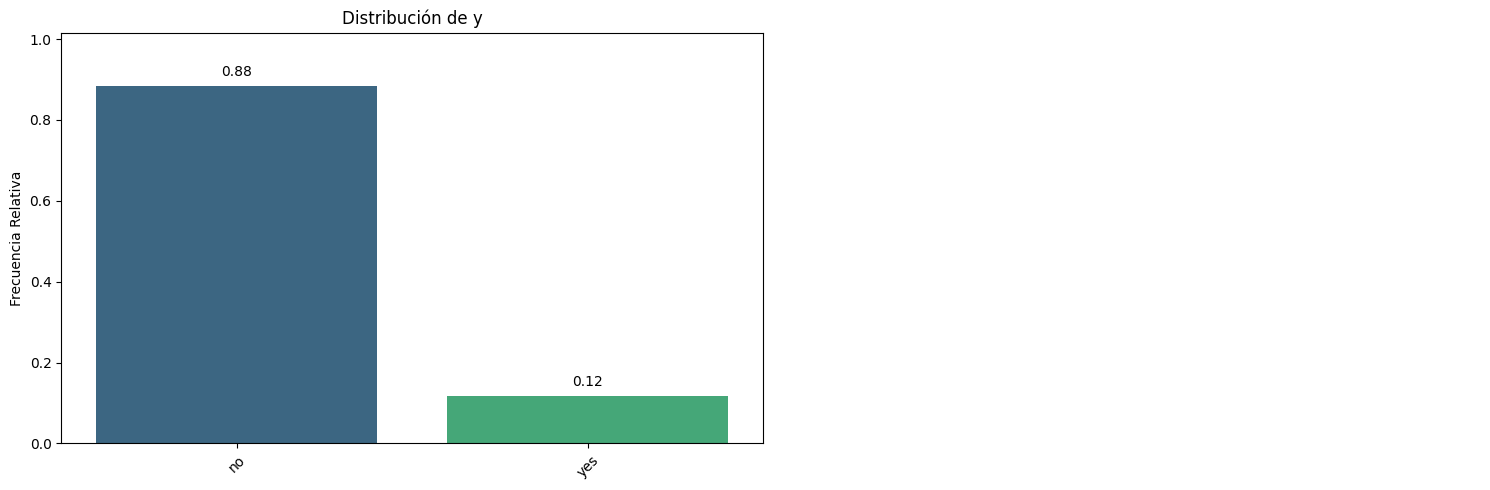

In [96]:
bt.pinta_distribucion_categoricas(df, [target], relativa= True, mostrar_valores= True)

In [ ]:
# no esta balanceado el target
# hay que tratarlo pero mas adelante

### TRAIN/TEST

In [98]:
train_set, test_set = train_test_split(df, test_size= 0.2, random_state= 73)

### MINIEDA

In [99]:
train_set.info()

<class 'pandas.DataFrame'>
Index: 36168 entries, 30323 to 21398
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        36168 non-null  int64
 1   job        36168 non-null  str  
 2   marital    36168 non-null  str  
 3   education  36168 non-null  str  
 4   default    36168 non-null  str  
 5   balance    36168 non-null  int64
 6   housing    36168 non-null  str  
 7   loan       36168 non-null  str  
 8   contact    36168 non-null  str  
 9   day        36168 non-null  int64
 10  month      36168 non-null  str  
 11  duration   36168 non-null  int64
 12  campaign   36168 non-null  int64
 13  pdays      36168 non-null  int64
 14  previous   36168 non-null  int64
 15  poutcome   36168 non-null  str  
 16  y          36168 non-null  str  
dtypes: int64(7), str(10)
memory usage: 5.0 MB


In [102]:
features_cat = train_set.select_dtypes(include = "object").columns.to_list()

if target in features_cat:
    features_cat.remove(target)
    
features_cat

C:\Users\anaco\AppData\Local\Temp\ipykernel_16436\3267497418.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  features_cat = train_set.select_dtypes(include = "object").columns.to_list()


['job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'month',
 'poutcome']

In [103]:
features_num = [col for col in train_set.columns if col not in features_cat and col != target]

features_num

['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

In [104]:
features_num = train_set.select_dtypes(exclude=["str"]).columns.tolist()
features_num

['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

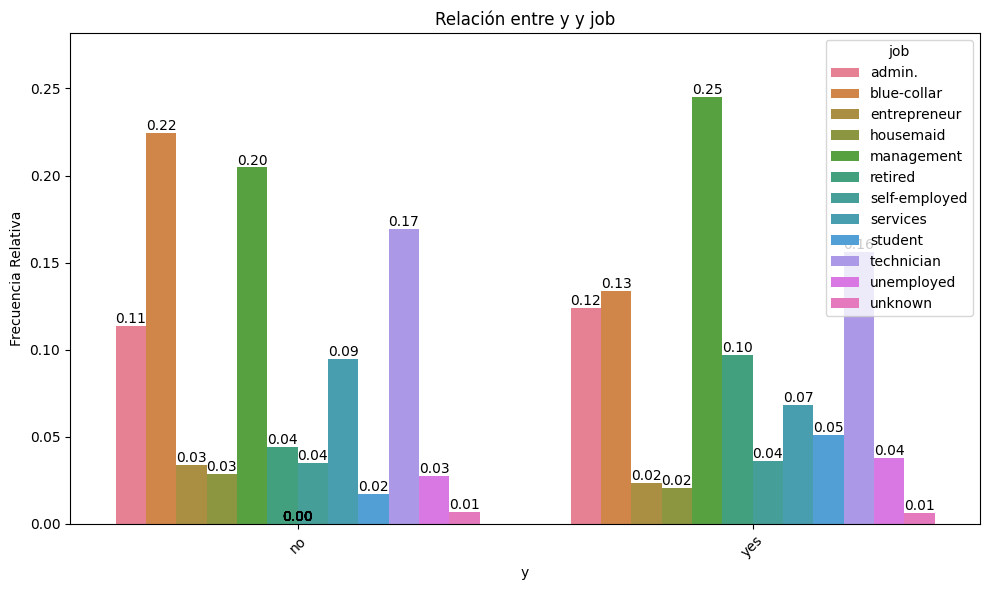

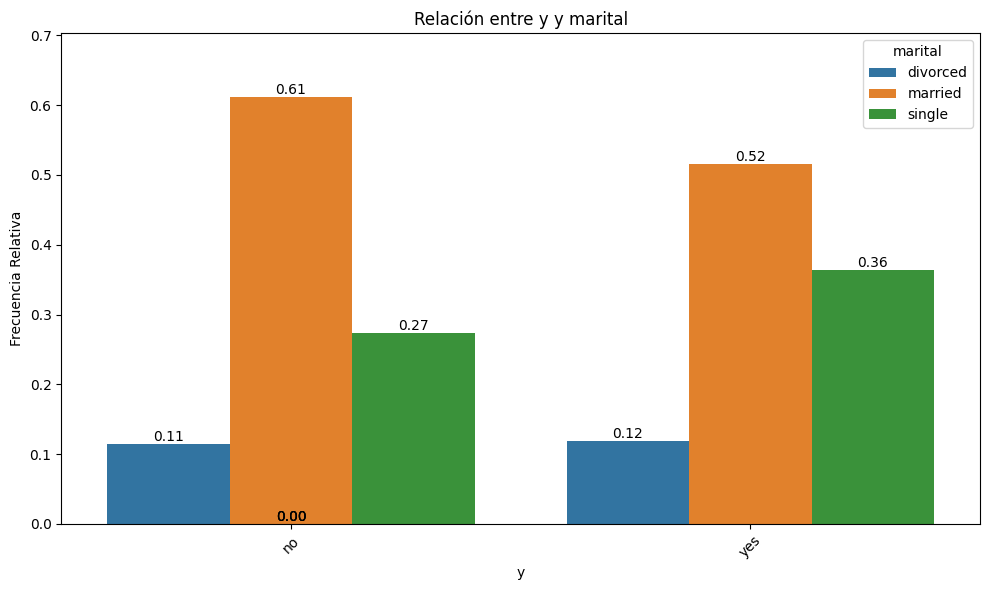

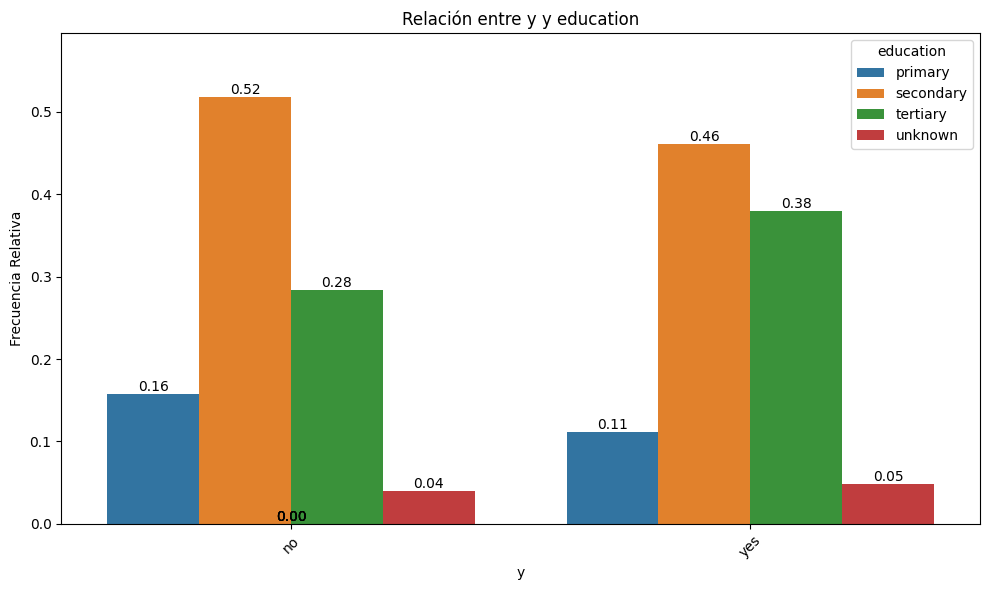

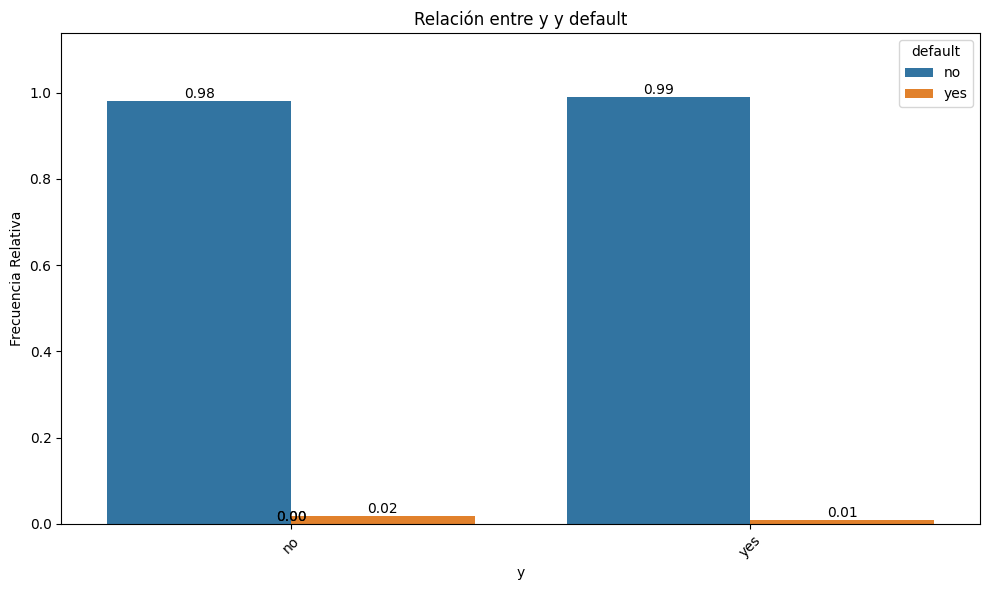

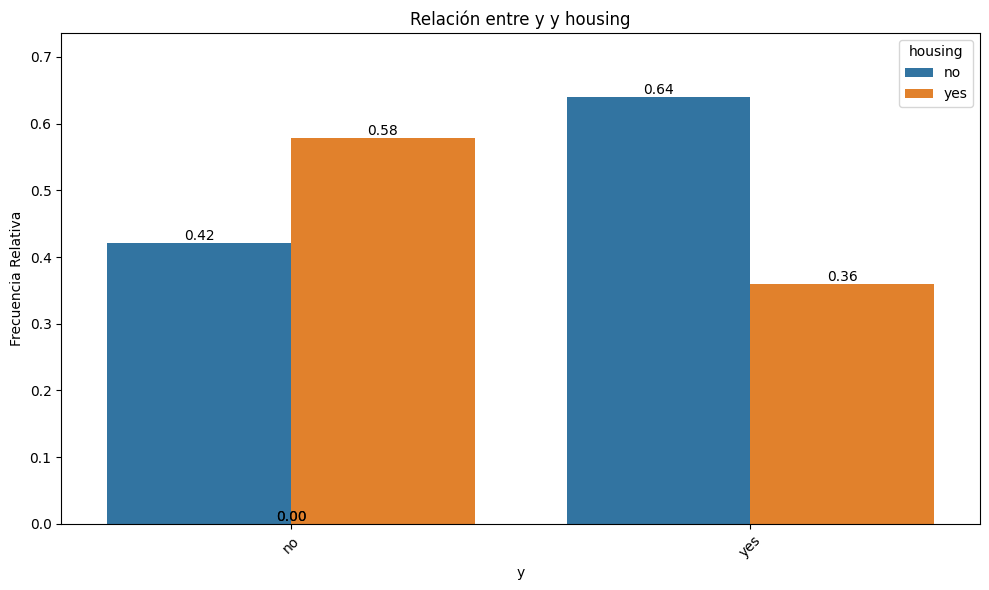

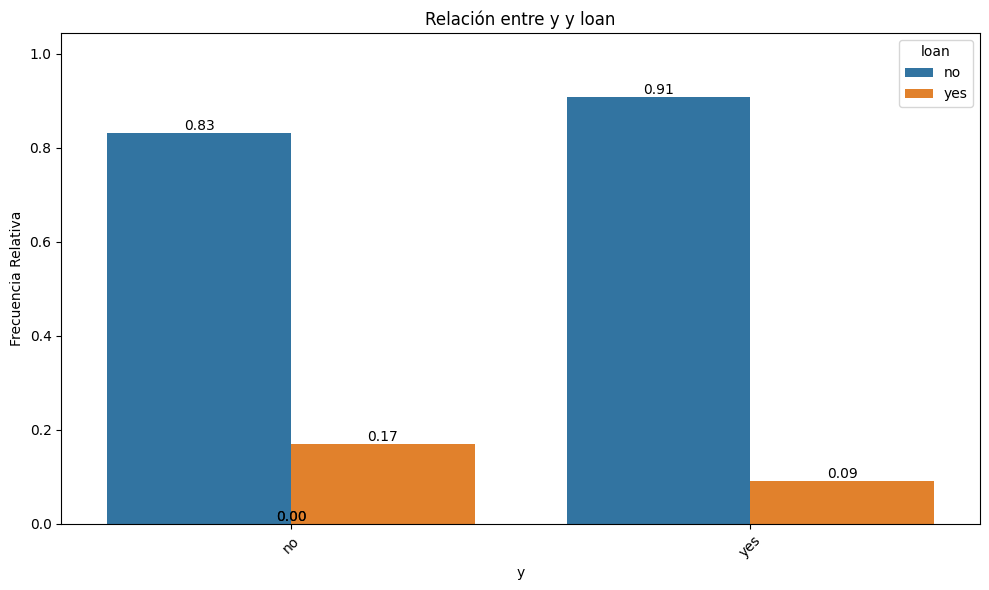

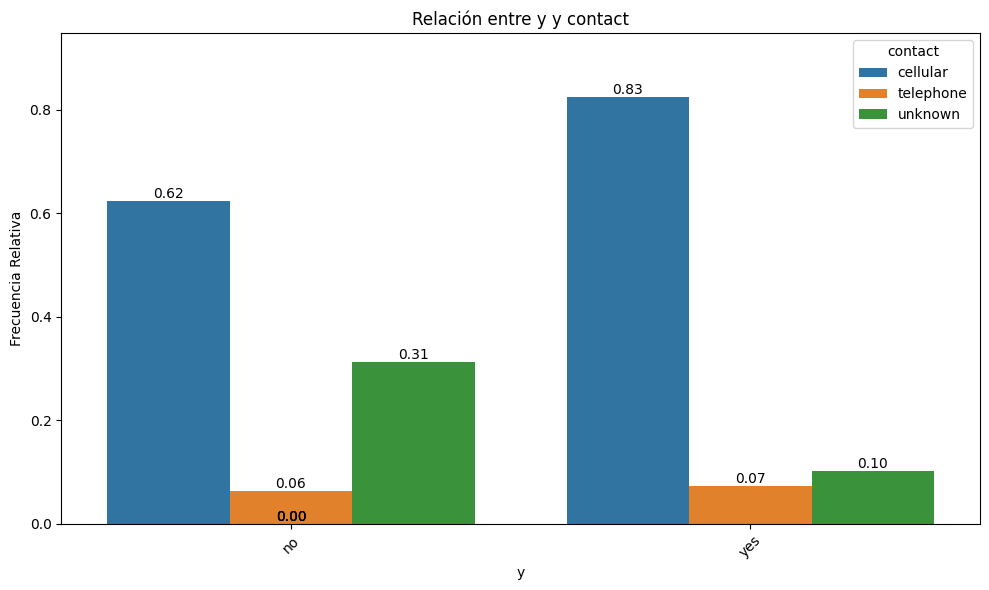

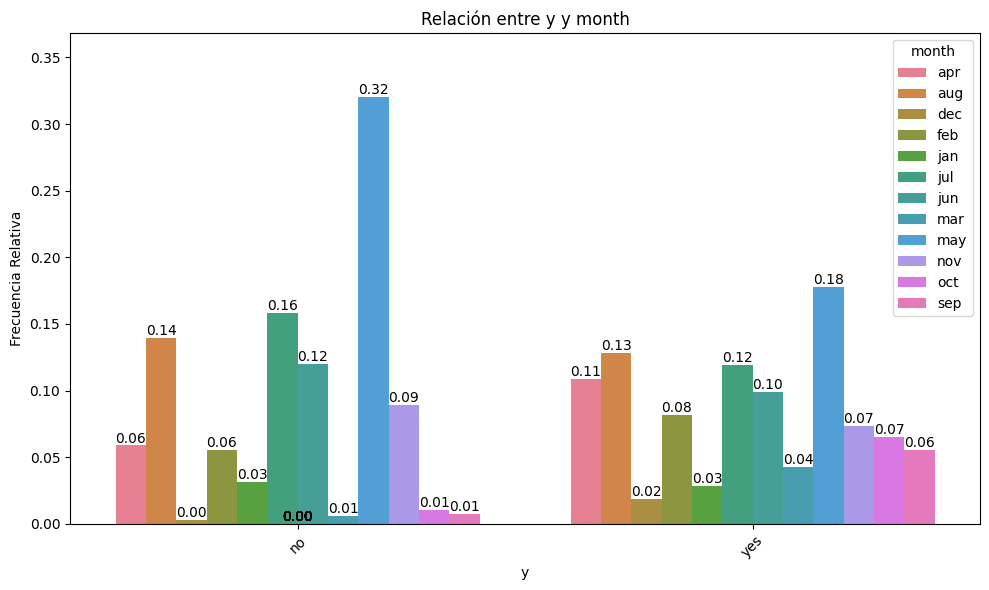

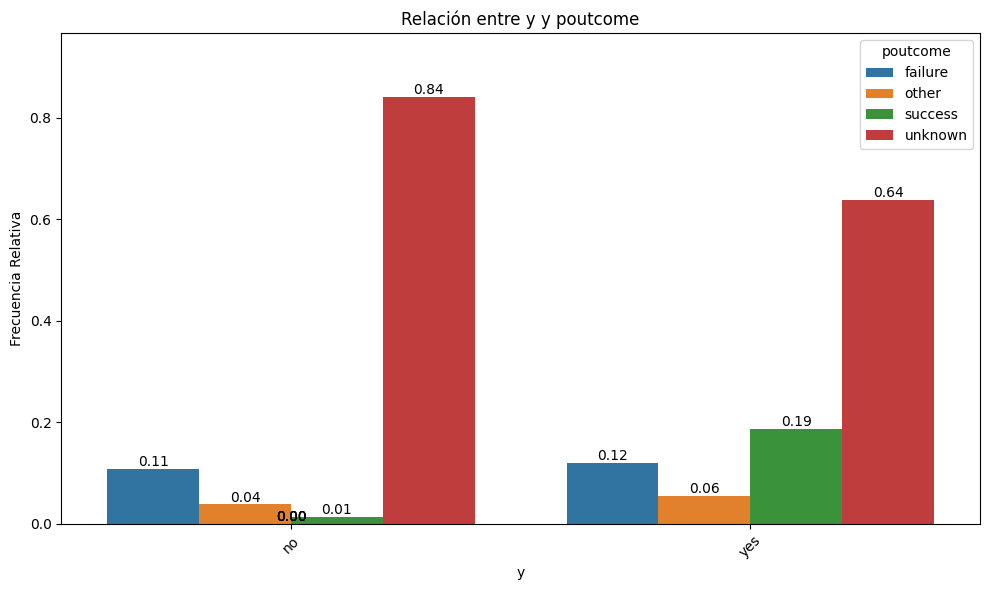

In [105]:
### categóricas

for col in features_cat:
    bt.plot_categorical_relationship(train_set, target, col, relative_freq= True, show_values= True)

*Parece que default no discrimina y la podríamos quitar, el resto las vamos a mantener para analizar el feature importance del módelo*


In [ ]:
# normalmente hay que hacer metricas, t student etc, pero no lo hacemos, ya sabemos las que nos quedamos y las que quitamos

In [106]:
features_cat.remove("default")

In [107]:
features_cat

['job',
 'marital',
 'education',
 'housing',
 'loan',
 'contact',
 'month',
 'poutcome']

###  Numéricas

In [19]:
# sns.pairplot(train_set, hue= target)

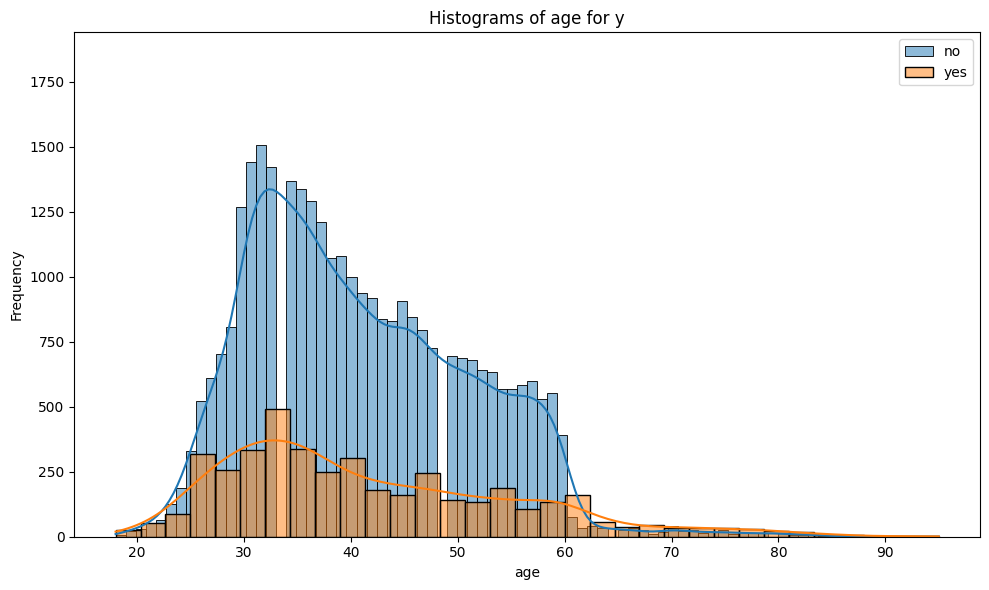

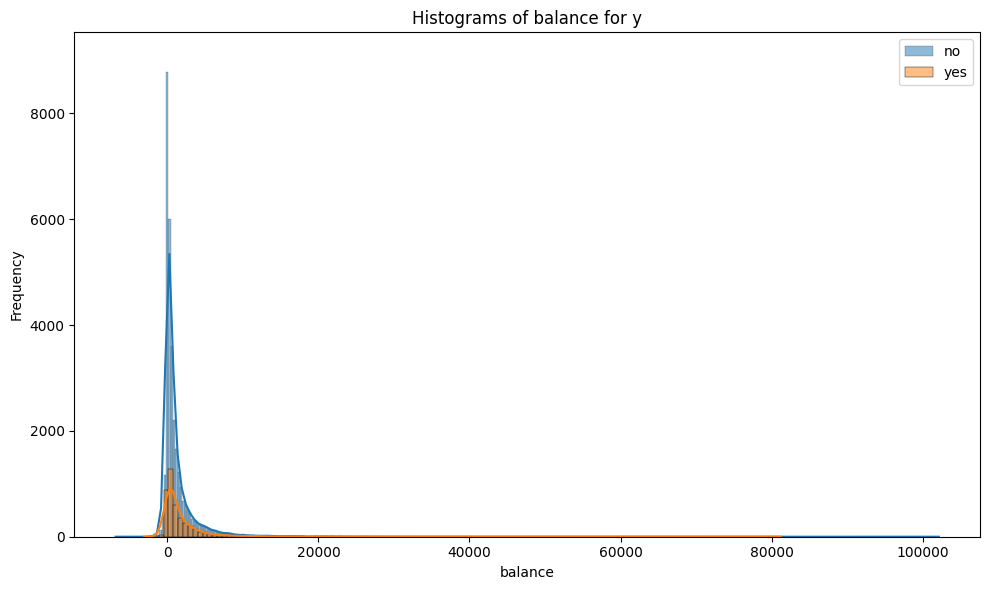

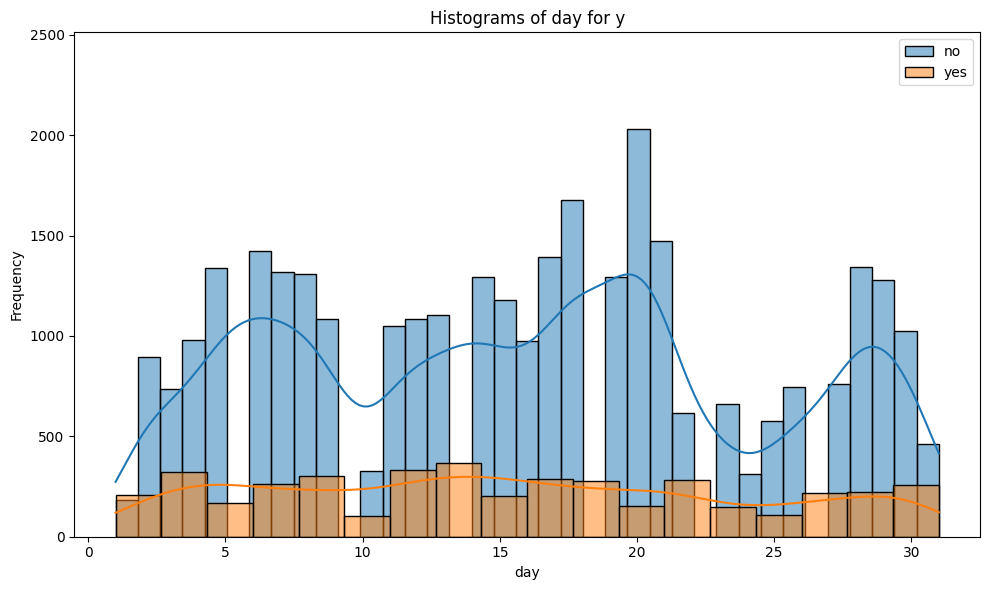

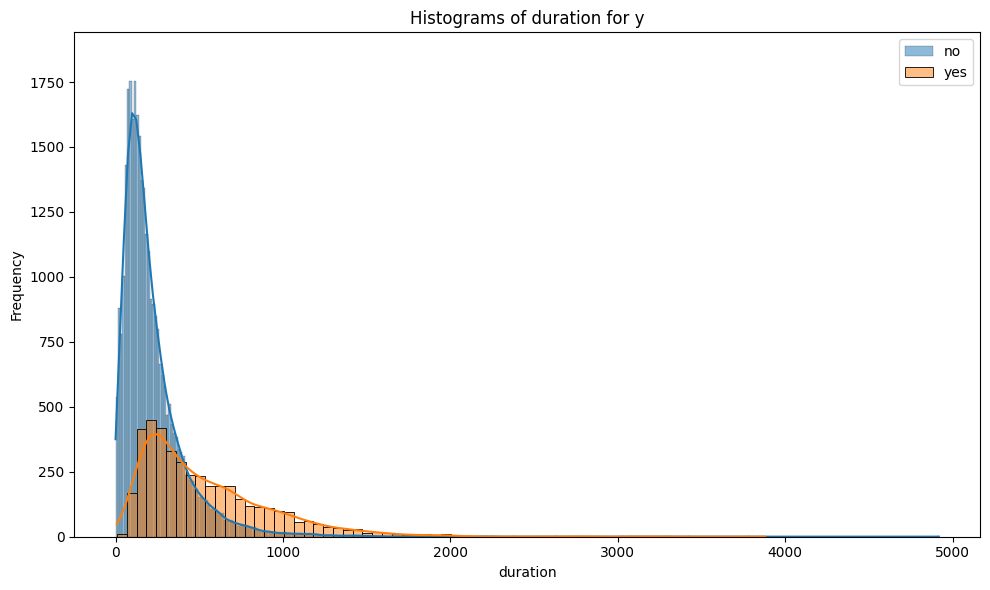

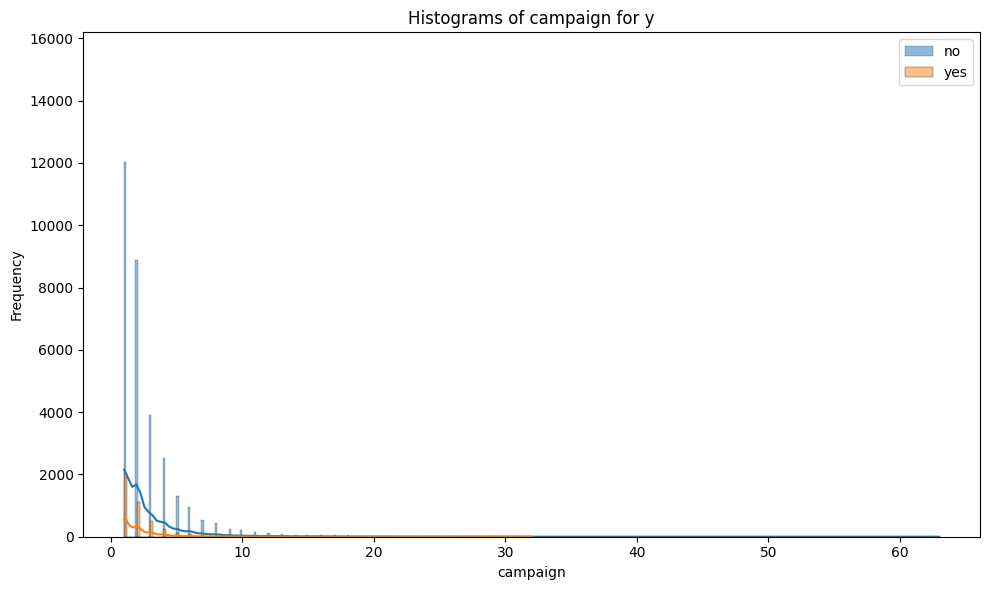

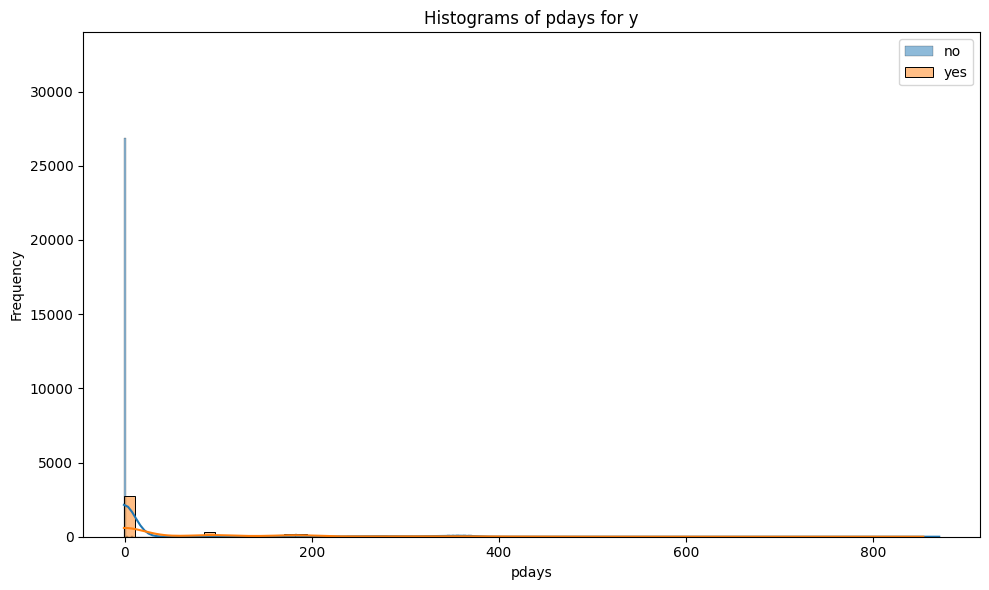

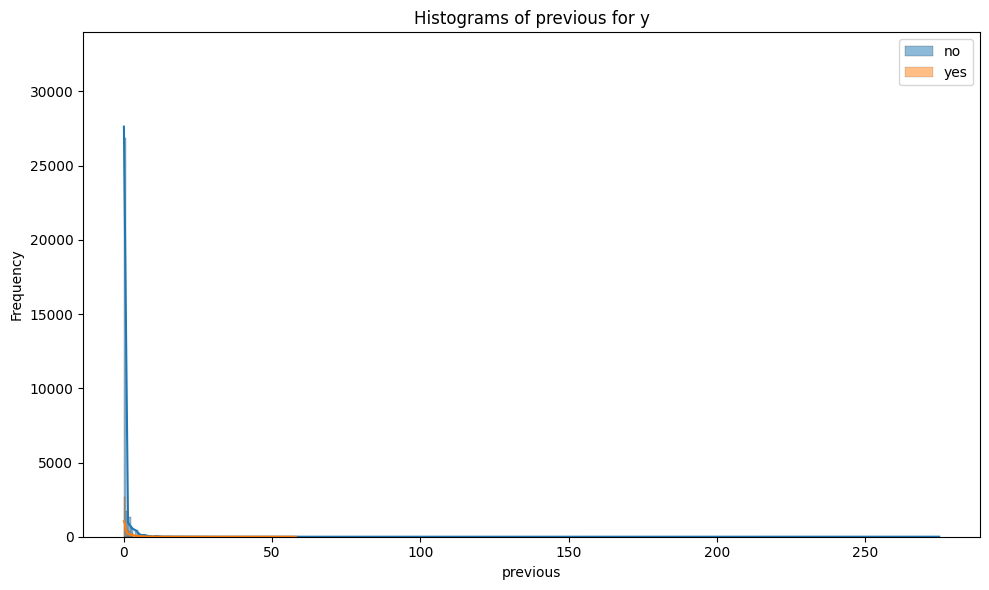

In [108]:
for col in features_num:
    bt.plot_grouped_histograms(train_set, cat_col= target, num_col= col, group_size= 2)

In [109]:
train_set["balance"].describe()

count     36168.000000
mean       1364.416418
std        3061.830610
min       -6847.000000
25%          73.000000
50%         448.000000
75%        1431.000000
max      102127.000000
Name: balance, dtype: float64

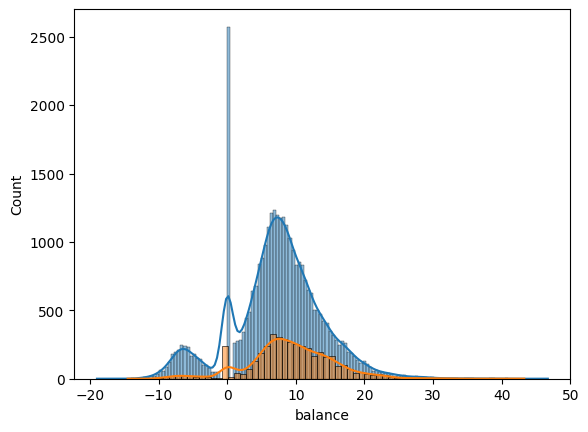

In [110]:
## histogramas individuales y transformar
col = "balance"

sns.histplot(np.cbrt(train_set[col][train_set["y"] == "no"]), kde=True) # Raíz cubíca ya que hay valores negativos grandes
sns.histplot(np.cbrt(train_set[col][train_set["y"] == "yes"]), kde=True)
plt.show()

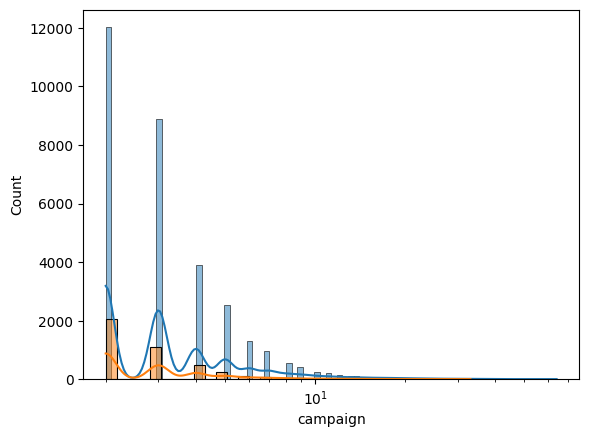

In [111]:
col = "campaign"
sns.histplot(train_set[col][train_set["y"] == "no"]+1, log_scale=10, kde=True) # Log(x+1) usando el argumento de log_scale
sns.histplot(train_set[col][train_set["y"] == "yes"]+1, log_scale=10, kde=True)
plt.show()

In [ ]:
train_set[features_cat].nunique()

# month diccionario

job          12
marital       3
education     4
housing       2
loan          2
contact       3
month        12
poutcome      4
dtype: int64

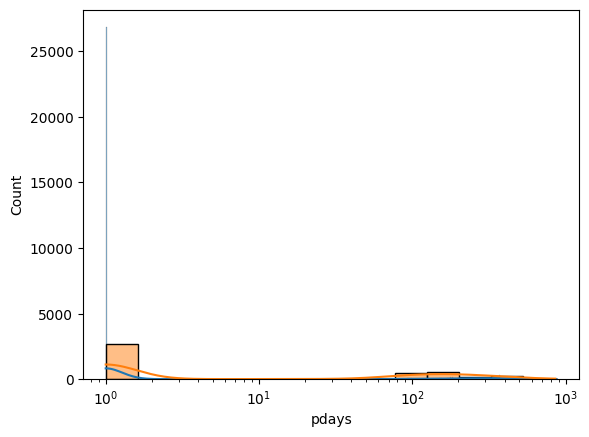

In [112]:
col = "pdays"
sns.histplot(train_set[col][train_set["y"] == "no"]+2, log_scale=10, kde=True) # Log(x+2) usando el argumento de log_scale
sns.histplot(train_set[col][train_set["y"] == "yes"]+2, log_scale=10, kde=True)
plt.show()

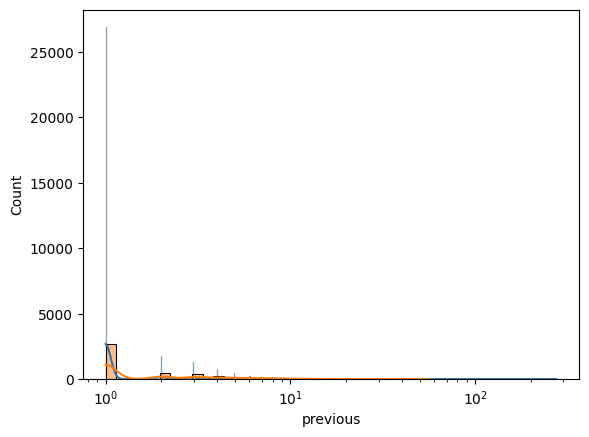

In [24]:
col = "previous"
sns.histplot(train_set[col][train_set["y"] == "no"]+1, log_scale=10, kde=True) # Log(x+1) usando el argumento de log_scale
sns.histplot(train_set[col][train_set["y"] == "yes"]+1, log_scale=10, kde=True)
plt.show()

In [25]:
features_num

['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

### Tratamiento

Categóricas:


In [114]:
train_set[features_cat].nunique()

job          12
marital       3
education     4
housing       2
loan          2
contact       3
month        12
poutcome      4
dtype: int64

Sabíamos que "housing" y "loan" son de tipo binario, por lo que las transformamos con máscaras de booleanos   
Y "month" como sabemos que una ordinal, la transformamos con mapeo usando un diccionario  
El resto las convertiremos en One-hot encoding con pd.get_dummies()

In [115]:
features_cat_sel = features_cat.copy() # Hacemos una copia de la lista de features categóricas para poder ir eliminando aquellas que vayamos tratando mientras mantenemos la selección

In [116]:
train_set["housing"] == "yes" # Máscara de booleanos de la variable housing

30323     True
34372    False
17239     True
33184     True
22545    False
         ...  
41281     True
8586      True
4014      True
24722    False
21398    False
Name: housing, Length: 36168, dtype: bool

In [117]:
train_set["housing"] = train_set["housing"] == "yes"
train_set["loan"] = train_set["loan"] == "yes"

test_set["housing"] = test_set["housing"] == "yes" # Lo mismo que hagamos en train, lo hacemos en test
test_set["loan"] = test_set["loan"] == "yes"

features_cat.remove("housing") # las quitamos de nuestra lista para no pasarlas por el One-hot encoding
features_cat.remove("loan")

In [ ]:
## month

In [118]:
month_dic = {
    "jan": 1,
    "feb": 2,
    "mar": 3,
    "apr": 4,
    "may": 5,
    "jun": 6,
    "jul": 7,
    "aug": 8,
    "sep": 9,
    "oct": 10,
    "nov": 11,
    "dec": 12
}

In [119]:
train_set["month"] = train_set["month"].map(month_dic)
test_set["month"] = test_set["month"].map(month_dic)

In [120]:
features_cat.remove("month") # la quitamos de nuestra lista para no pasarla por el One-hot encoding

In [121]:
train_set = pd.get_dummies(train_set, columns = features_cat, dtype = int)
test_set = pd.get_dummies(test_set, columns = features_cat, dtype = int)

In [122]:
train_set.shape # Comprobamos que las dimensiones concuerdan

(36168, 38)

In [35]:
test_set.shape

(9043, 38)

In [ ]:
# numericas

Ahora tratamos las features_num  

En principio no pasa nada por no escalar porque los árboles no lo requieren, podemos hacerlo y probar dos modelos.  
PERO como hay que hacer un baseline con un regresor logístico, al reg. logístico sí que le afecta la escala ¡y mucho!

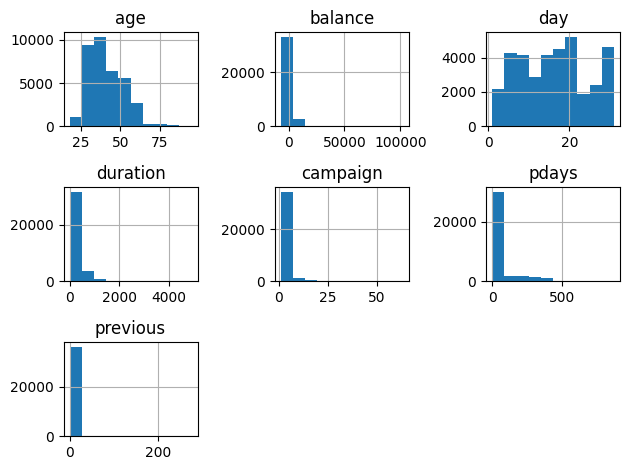

In [124]:
train_set[features_num].hist()
plt.tight_layout()

In [41]:
## Transformaremos todas excepto "age" y "day"
## Y recuerda que pdays tiene un valor -1 del que podemos extraer una nueva variable categórica que llamaremos "contacted_before"

In [125]:
train_set["pdays"] != -1

30323     True
34372    False
17239    False
33184    False
22545    False
         ...  
41281     True
8586     False
4014     False
24722    False
21398    False
Name: pdays, Length: 36168, dtype: bool

In [126]:
train_set["contacted_before"] = train_set["pdays"] != -1

In [127]:
test_set["contacted_before"] = test_set["pdays"] != -1

In [128]:
# train_set["contacted_before"] = train_set["pdays"].apply(before_contact) # en caso de definir una función de usuario "before_contact"
# train_set["contacted_before"] = train_set["pdays"].apply(lambda row: 1 if row >= 0 else 0)
# test_set["contacted_before"] = test_set["pdays"].apply(lambda row: 1 if row >= 0 else 0)

train_set.contacted_before.value_counts(True)

contacted_before
False    0.817048
True     0.182952
Name: proportion, dtype: float64

In [46]:
## Analizamos la nueva variable como categórica y vemos como es la distribución de pdays quitando el valor -1

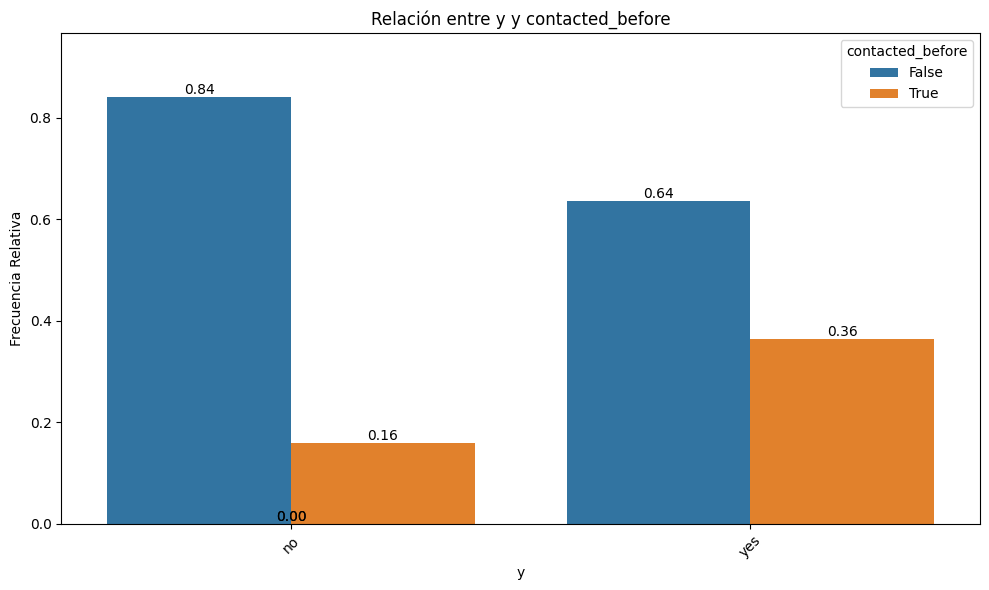

In [43]:
bt.plot_categorical_relationship(train_set, target, "contacted_before", relative_freq= True, show_values= True)

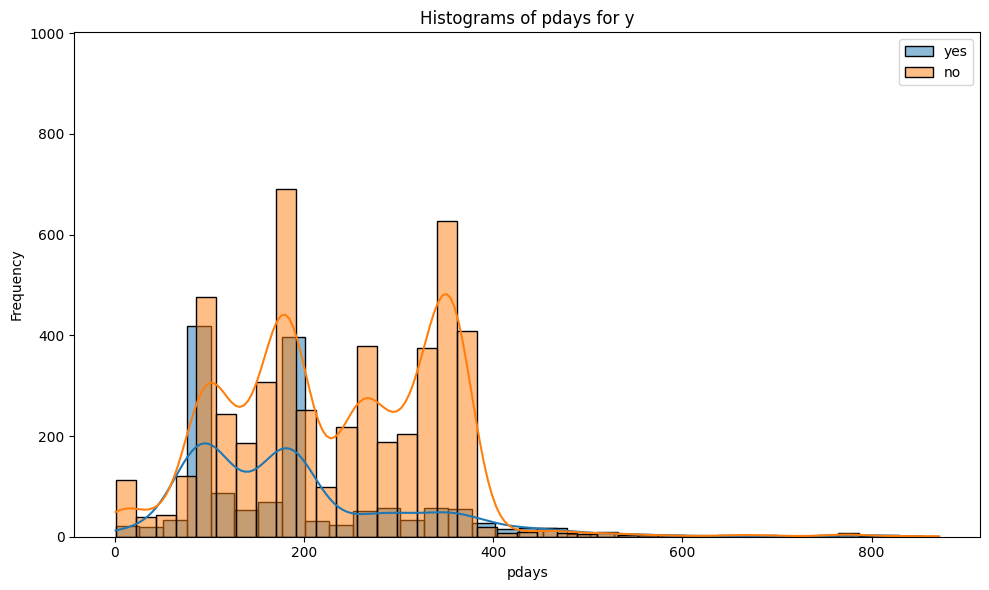

In [44]:
bt.plot_grouped_histograms(train_set[train_set.contacted_before == 1], cat_col= target, num_col= "pdays", group_size= 2)

Incluimos "contacted before" en nuestra lista de categóricas

In [45]:
features_cat_sel.append("contacted_before")

train_set_scaled = train_set.copy()
test_set_scaled = test_set.copy()

#### En base a lo aprendido, transformamos y escalamos Numéricas

In [129]:
features_num

['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

In [130]:
train_set_scaled["balance"] = np.cbrt(train_set_scaled["balance"])
train_set_scaled["duration"] = np.log(train_set_scaled["duration"] + 1)
train_set_scaled["campaign"] = np.log(train_set_scaled["campaign"])
train_set_scaled["pdays"] = np.log(train_set_scaled["pdays"] + 2)
train_set_scaled["previous"] = np.log(train_set_scaled["previous"] + 1)

c:\Users\anaco\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [131]:
test_set_scaled["balance"] = np.cbrt(test_set_scaled["balance"])
test_set_scaled["duration"] = np.log(test_set_scaled["duration"] + 1)
test_set_scaled["campaign"] = np.log(test_set_scaled["campaign"])
test_set_scaled["pdays"] = np.log(test_set_scaled["pdays"] + 2)
test_set_scaled["previous"] = np.log(test_set_scaled["previous"] + 1)

In [132]:
train_set_scaled[features_num]

,age,balance,day,duration,campaign,pdays,previous
3344,0.006515,0.674553,-0.098218,-3.019390,NaN,0.426678,-0.553600
17965,0.759937,0.830548,1.703422,0.383768,NaN,0.426678,-0.553600
18299,0.100693,1.075522,1.823532,-0.380972,-0.046985,0.426678,-0.553600
10221,-0.370196,-1.232059,-0.578656,0.602718,0.864251,0.426678,-0.553600
32192,1.419181,1.054073,-0.098218,0.369856,NaN,0.426678,-0.553600
...,...,...,...,...,...,...,...
11284,0.289048,0.746793,0.262110,1.305645,NaN,0.426678,-0.553600
44732,-1.688684,0.433545,-0.938984,0.182583,NaN,1.321374,0.628658
38158,-0.652729,0.810669,-0.098218,0.292688,NaN,0.426678,-0.553600
860,-0.746907,-0.666409,-1.059093,-0.667091,NaN,0.426678,-0.553600


In [133]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

train_set_scaled[features_num] = scaler.fit_transform(train_set_scaled[features_num])
test_set_scaled[features_num] = scaler.transform(test_set_scaled[features_num])

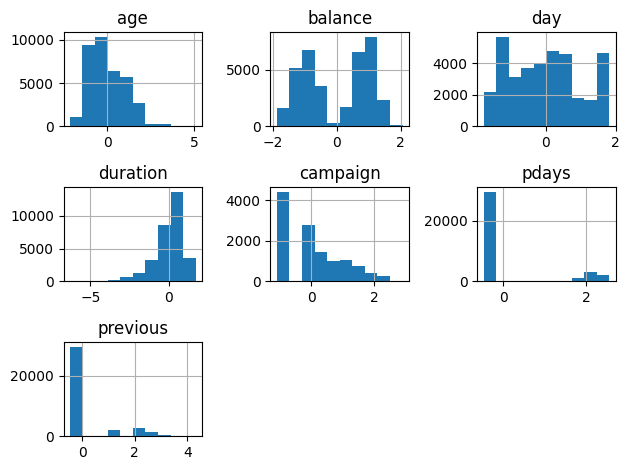

In [134]:
train_set_scaled[features_num].hist()
plt.tight_layout()

### Importamos modelos, entrenamos, creamos el baseline

In [135]:
features_cat_sel # Ojo, recuerda que hemos hecho get_dummies, las columnas del dataset ya no son las que tenemos en nuestra selección

['job',
 'marital',
 'education',
 'housing',
 'loan',
 'contact',
 'month',
 'poutcome']

In [136]:
train_set.columns

Index(['age', 'default', 'balance', 'housing', 'loan', 'day', 'month',
       'duration', 'campaign', 'pdays', 'previous', 'y', 'job_admin.',
       'job_blue-collar', 'job_entrepreneur', 'job_housemaid',
       'job_management', 'job_retired', 'job_self-employed', 'job_services',
       'job_student', 'job_technician', 'job_unemployed', 'job_unknown',
       'marital_divorced', 'marital_married', 'marital_single',
       'education_primary', 'education_secondary', 'education_tertiary',
       'education_unknown', 'contact_cellular', 'contact_telephone',
       'contact_unknown', 'poutcome_failure', 'poutcome_other',
       'poutcome_success', 'poutcome_unknown', 'contacted_before'],
      dtype='str')

In [137]:
features_encoded_cat_sel = []

for col in features_cat_sel:
    defintive_col = [col_2 for col_2 in train_set.columns if col_2.startswith(col)]
    features_encoded_cat_sel += defintive_col

features_encoded_cat_sel

['job_admin.',
 'job_blue-collar',
 'job_entrepreneur',
 'job_housemaid',
 'job_management',
 'job_retired',
 'job_self-employed',
 'job_services',
 'job_student',
 'job_technician',
 'job_unemployed',
 'job_unknown',
 'marital_divorced',
 'marital_married',
 'marital_single',
 'education_primary',
 'education_secondary',
 'education_tertiary',
 'education_unknown',
 'housing',
 'loan',
 'contact_cellular',
 'contact_telephone',
 'contact_unknown',
 'contacted_before',
 'month',
 'poutcome_failure',
 'poutcome_other',
 'poutcome_success',
 'poutcome_unknown']

In [138]:
## En este punto podrías transformar el target en etiquetas 0 y 1 si quieres

# def convertir(row):
#     return 1 if row == "yes" else 0 

# train_set[target] = train_set[target].apply(lambda row: 1 if row == "yes" else 0) # apply(convertir)
# test_set[target] = test_set[target].apply(lambda row: 1 if row == "yes" else 0)

In [139]:
X_train = train_set[features_encoded_cat_sel + features_num].copy()
X_train_scaled = train_set_scaled[features_encoded_cat_sel + features_num].copy()
y_train = train_set[target]

X_test = test_set[features_encoded_cat_sel + features_num].copy()
X_test_scaled = test_set_scaled[features_encoded_cat_sel + features_num].copy()
y_test = test_set[target]

In [141]:
X_train_scaled

,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,...,poutcome_other,poutcome_success,poutcome_unknown,age,balance,day,duration,campaign,pdays,previous
3344,0,1,0,0,0,0,0,0,0,0,...,0,0,1,0.006515,0.749976,-0.098218,-3.316546,NaN,-0.470234,-0.460536
17965,0,0,0,0,0,0,0,0,0,1,...,0,0,1,0.759937,0.929849,1.703422,0.463827,NaN,-0.470234,-0.460536
18299,1,0,0,0,0,0,0,0,0,0,...,0,0,1,0.100693,1.212322,1.823532,-0.385678,-0.084921,-0.470234,-0.460536
10221,0,0,0,0,1,0,0,0,0,0,...,0,0,1,-0.370196,-1.448490,-0.578656,0.707046,1.594646,-0.470234,-0.460536
32192,0,1,0,0,0,0,0,0,0,0,...,0,0,1,1.419181,1.187590,-0.098218,0.448373,NaN,-0.470234,-0.460536
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,0,0,0,1,0,0,0,0,0,0,...,0,0,1,0.289048,0.833274,0.262110,1.487887,NaN,-0.470234,-0.460536
44732,0,0,0,0,0,0,0,0,1,0,...,0,0,0,-1.688684,0.472075,-0.938984,0.240342,NaN,1.882859,1.446351
38158,0,0,0,0,0,0,0,0,0,1,...,0,0,1,-0.652729,0.906927,-0.098218,0.362651,NaN,-0.470234,-0.460536
860,0,0,0,0,0,1,0,0,0,0,...,0,0,1,-0.746907,-0.796254,-1.059093,-0.703512,NaN,-0.470234,-0.460536


In [144]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

lr_clf = LogisticRegression(max_iter = 1000)
tree_clf = DecisionTreeClassifier(random_state = 72) # Los árboles sin limite sobreajustan -> esto lo dejamos a modo de ejemplo

lr_clf.fit(X_train_scaled, y_train) # Entrenamos el regresor logístico

ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [145]:
print(classification_report(y_train, lr_clf.predict(X_train_scaled)))

ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [58]:
print(classification_report(y_test, lr_clf.predict(X_test_scaled)))

              precision    recall  f1-score   support

          no       0.91      0.98      0.94      7952
         yes       0.66      0.33      0.44      1091

    accuracy                           0.90      9043
   macro avg       0.78      0.65      0.69      9043
weighted avg       0.88      0.90      0.88      9043



In [59]:
tree_clf.fit(X_train, y_train) # Entrenamos el árbol de decisión

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [60]:
print(classification_report(y_train, tree_clf.predict(X_train))) # Overfitting

              precision    recall  f1-score   support

          no       1.00      1.00      1.00     31970
         yes       1.00      1.00      1.00      4198

    accuracy                           1.00     36168
   macro avg       1.00      1.00      1.00     36168
weighted avg       1.00      1.00      1.00     36168



In [61]:
print(classification_report(y_test, tree_clf.predict(X_test)))

              precision    recall  f1-score   support

          no       0.93      0.93      0.93      7952
         yes       0.48      0.50      0.49      1091

    accuracy                           0.87      9043
   macro avg       0.71      0.71      0.71      9043
weighted avg       0.88      0.87      0.88      9043



In [62]:
from sklearn.model_selection import GridSearchCV # o en caso de tener un grid muy grande -> RandozimedSearchCV

param_grid = {
    "max_depth": [1,2,8,10],
    "min_samples_leaf": [1,10,20,100],
    "max_features": ["sqrt", "log2", None],
    "class_weight": ["balanced", None]
}

tree_clf = DecisionTreeClassifier(random_state= 42)

tree_grid = GridSearchCV(tree_clf,
                        param_grid= param_grid,
                        cv = 5,
                        scoring = "balanced_accuracy") # Depende del impacto en el problema de negocio

tree_grid.fit(X_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'class_weight': ['balanced', None], 'max_depth': [1, 2, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [1, 10, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'balanced_accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation tim

In [63]:
from sklearn.metrics import get_scorer_names
get_scorer_names()

['accuracy',
 'adjusted_mutual_info_score',
 'adjusted_rand_score',
 'average_precision',
 'balanced_accuracy',
 'completeness_score',
 'd2_absolute_error_score',
 'd2_brier_score',
 'd2_log_loss_score',
 'explained_variance',
 'f1',
 'f1_macro',
 'f1_micro',
 'f1_samples',
 'f1_weighted',
 'fowlkes_mallows_score',
 'homogeneity_score',
 'jaccard',
 'jaccard_macro',
 'jaccard_micro',
 'jaccard_samples',
 'jaccard_weighted',
 'matthews_corrcoef',
 'mutual_info_score',
 'neg_brier_score',
 'neg_log_loss',
 'neg_max_error',
 'neg_mean_absolute_error',
 'neg_mean_absolute_percentage_error',
 'neg_mean_gamma_deviance',
 'neg_mean_poisson_deviance',
 'neg_mean_squared_error',
 'neg_mean_squared_log_error',
 'neg_median_absolute_error',
 'neg_negative_likelihood_ratio',
 'neg_root_mean_squared_error',
 'neg_root_mean_squared_log_error',
 'normalized_mutual_info_score',
 'positive_likelihood_ratio',
 'precision',
 'precision_macro',
 'precision_micro',
 'precision_samples',
 'precision_weighte

In [64]:
tree_grid.best_params_

{'class_weight': 'balanced',
 'max_depth': 10,
 'max_features': None,
 'min_samples_leaf': 20}

In [65]:
tree_grid.best_score_

np.float64(0.8365664720350253)

In [66]:
tree_grid.best_estimator_

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",20
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [67]:
y_pred = tree_grid.best_estimator_.predict(X_train)

print(classification_report(y_train, y_pred))

              precision    recall  f1-score   support

          no       0.99      0.82      0.89     31970
         yes       0.40      0.93      0.56      4198

    accuracy                           0.83     36168
   macro avg       0.69      0.87      0.72     36168
weighted avg       0.92      0.83      0.85     36168



In [68]:
y_pred = tree_grid.best_estimator_.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          no       0.98      0.80      0.88      7952
         yes       0.37      0.87      0.52      1091

    accuracy                           0.81      9043
   macro avg       0.68      0.83      0.70      9043
weighted avg       0.90      0.81      0.84      9043



In [69]:
tree_grid.best_estimator_.feature_importances_

array([6.52999797e-04, 2.45814434e-03, 4.90885954e-05, 0.00000000e+00,
       1.41073509e-03, 2.95821150e-04, 0.00000000e+00, 4.66286946e-04,
       0.00000000e+00, 6.04760610e-04, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 1.63172656e-03, 4.58453653e-04, 9.71155451e-06,
       1.54120137e-18, 1.50928975e-03, 0.00000000e+00, 4.71928421e-02,
       6.82068298e-03, 2.28824773e-04, 3.41849157e-04, 1.07679275e-01,
       0.00000000e+00, 1.24366711e-01, 0.00000000e+00, 0.00000000e+00,
       1.16640569e-01, 0.00000000e+00, 0.00000000e+00, 1.45876434e-02,
       2.34959411e-02, 5.60903165e-02, 4.62715358e-01, 5.15758495e-03,
       2.49950910e-02, 1.40292505e-04])

In [70]:
tree_grid.best_estimator_.feature_names_in_

array(['job_admin.', 'job_blue-collar', 'job_entrepreneur',
       'job_housemaid', 'job_management', 'job_retired',
       'job_self-employed', 'job_services', 'job_student',
       'job_technician', 'job_unemployed', 'job_unknown',
       'marital_divorced', 'marital_married', 'marital_single',
       'education_primary', 'education_secondary', 'education_tertiary',
       'education_unknown', 'housing', 'loan', 'contact_cellular',
       'contact_telephone', 'contact_unknown', 'contacted_before',
       'month', 'poutcome_failure', 'poutcome_other', 'poutcome_success',
       'poutcome_unknown', 'contacted_before', 'age', 'balance', 'day',
       'duration', 'campaign', 'pdays', 'previous'], dtype=object)

In [71]:
df_feat_importance = pd.DataFrame({"features": tree_grid.best_estimator_.feature_names_in_, "importancia": tree_grid.best_estimator_.feature_importances_}).sort_values("importancia",ascending=False)
df_feat_importance

,features,importancia
34,duration,4.627154e-01
25,month,1.243667e-01
28,poutcome_success,1.166406e-01
23,contact_unknown,1.076793e-01
33,day,5.609032e-02
19,housing,4.719284e-02
36,pdays,2.499509e-02
32,balance,2.349594e-02
31,age,1.458764e-02
20,loan,6.820683e-03


#### EXTRA: Usamos el feature importance del modelo para hacer selección de features y valorar los resultados

In [72]:
num_features = 10
df_feat_importance.iloc[:num_features,:]

,features,importancia
34,duration,0.462715
25,month,0.124367
28,poutcome_success,0.116641
23,contact_unknown,0.107679
33,day,0.056090
19,housing,0.047193
36,pdays,0.024995
32,balance,0.023496
31,age,0.014588
20,loan,0.006821


In [73]:
new_features_sel = df_feat_importance.iloc[:num_features,:]["features"].to_list()
new_features_sel

['duration',
 'month',
 'poutcome_success',
 'contact_unknown',
 'day',
 'housing',
 'pdays',
 'balance',
 'age',
 'loan']

In [74]:
X_train = train_set[new_features_sel].copy()
X_train_scaled = train_set_scaled[new_features_sel].copy()
y_train = train_set[target]

X_test = test_set[new_features_sel].copy()
X_test_scaled = test_set_scaled[new_features_sel].copy()
y_test = test_set[target]

In [75]:
lr_clf = LogisticRegression(max_iter = 1000)
tree_clf = DecisionTreeClassifier(random_state= 42)

lr_clf.fit(X_train_scaled, y_train) # Entrenamos un nuevo regresor logístico

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [76]:
print(classification_report(y_train, lr_clf.predict(X_train_scaled)))

              precision    recall  f1-score   support

          no       0.92      0.98      0.95     31970
         yes       0.65      0.32      0.43      4198

    accuracy                           0.90     36168
   macro avg       0.78      0.65      0.69     36168
weighted avg       0.89      0.90      0.89     36168



In [77]:
print(classification_report(y_test, lr_clf.predict(X_test_scaled)))

              precision    recall  f1-score   support

          no       0.91      0.98      0.94      7952
         yes       0.64      0.31      0.42      1091

    accuracy                           0.90      9043
   macro avg       0.78      0.64      0.68      9043
weighted avg       0.88      0.90      0.88      9043



In [78]:
tree_clf.fit(X_train, y_train) # Entrenamos de nuevo el árbol de decisión

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [79]:
print(classification_report(y_train, tree_clf.predict(X_train))) # Overfitting

              precision    recall  f1-score   support

          no       1.00      1.00      1.00     31970
         yes       1.00      1.00      1.00      4198

    accuracy                           1.00     36168
   macro avg       1.00      1.00      1.00     36168
weighted avg       1.00      1.00      1.00     36168



In [80]:
print(classification_report(y_test, tree_clf.predict(X_test)))

              precision    recall  f1-score   support

          no       0.93      0.93      0.93      7952
         yes       0.47      0.47      0.47      1091

    accuracy                           0.87      9043
   macro avg       0.70      0.70      0.70      9043
weighted avg       0.87      0.87      0.87      9043



In [81]:
param_grid = {
    "max_depth": [1,2,8,10],
    "min_samples_leaf": [1,10,20,100],
    "max_features": ["sqrt", "log2", None],
    "class_weight": ["balanced", None]
}

tree_clf = DecisionTreeClassifier(random_state= 42)

tree_grid = GridSearchCV(tree_clf,
                        param_grid= param_grid,
                        cv = 5,
                        scoring = "balanced_accuracy") # Depende del impacto en el problema de negocio

tree_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'class_weight': ['balanced', None], 'max_depth': [1, 2, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [1, 10, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'balanced_accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation tim

In [82]:
tree_grid.best_params_

{'class_weight': 'balanced',
 'max_depth': 10,
 'max_features': None,
 'min_samples_leaf': 20}

In [83]:
tree_grid.best_score_

np.float64(0.8398781257643299)

In [84]:
tree_grid.best_estimator_

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",20
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [85]:
y_pred = tree_grid.best_estimator_.predict(X_train)

print(classification_report(y_train, y_pred))

              precision    recall  f1-score   support

          no       0.99      0.81      0.89     31970
         yes       0.39      0.93      0.55      4198

    accuracy                           0.82     36168
   macro avg       0.69      0.87      0.72     36168
weighted avg       0.92      0.82      0.85     36168



In [86]:
y_pred = tree_grid.best_estimator_.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          no       0.98      0.80      0.88      7952
         yes       0.37      0.87      0.52      1091

    accuracy                           0.80      9043
   macro avg       0.67      0.83      0.70      9043
weighted avg       0.90      0.80      0.83      9043



In [87]:
df_feat_importance = pd.DataFrame({"features": tree_grid.best_estimator_.feature_names_in_, "importancia": tree_grid.best_estimator_.feature_importances_}).sort_values("importancia",ascending=False)
df_feat_importance

,features,importancia
0,duration,0.469291
1,month,0.125906
2,poutcome_success,0.117384
3,contact_unknown,0.108366
4,day,0.057563
5,housing,0.047689
6,pdays,0.026241
7,balance,0.025734
8,age,0.014963
9,loan,0.006864


En conclusión, si reentrenamos nuestros modelos con solo las 10 features más importantes vemos que sus metricas siguen siendo prácticamente iguales.  

Prueba a modificar el criterio del número de features seleccionadas para ver en qué momento el rendimiento del modelo empeora significativamente.